# SMS Sentiment Analysis

In [4]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import datetime
from dateutil import parser  
import matplotlib.pyplot as plt
import seaborn as sns

#nltk.download('vader_lexicon')
#nltk.download('punkt') 

In [5]:
df = pd.read_csv('/Users/robertwrobel/Downloads/Messages - MS.csv')
df.head()

/var/folders/6t/1_v9ync132lgs0k2f0d3t9mc0000gn/T/ipykernel_87714/3319732034.py:1: DtypeWarning: Columns (7,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/robertwrobel/Downloads/Messages - MS.csv')


,Chat Session,Message Date,Delivered Date,Read Date,Edited Date,Service,Type,Sender ID,Sender Name,Status,Replying to,Subject,Text,Attachment,Attachment type
0,MS,5/24/24 19:13,5/24/24 19:13,NaN,NaN,iMessage,Outgoing,NaN,NaN,Read,NaN,NaN,For your reading “enjoyment” / relevant for to...,NaN,NaN
1,MS,5/25/24 07:46,NaN,5/25/24 09:37,NaN,iMessage,Incoming,17193213627,MS,Read,NaN,NaN,That’s a lot to unpack!,NaN,NaN
2,MS,5/25/24 09:38,NaN,NaN,NaN,iMessage,Outgoing,NaN,NaN,Read,NaN,NaN,Yep. A lot of nonsense.,NaN,NaN
3,MS,5/25/24 12:18,NaN,NaN,NaN,iMessage,Outgoing,NaN,NaN,Read,NaN,NaN,Just called. Went to voicemail,NaN,NaN
4,MS,5/25/24 12:38,NaN,NaN,NaN,iMessage,Outgoing,NaN,NaN,Read,NaN,NaN,She canceled on me 10 minutes before. She says...,NaN,NaN


In [8]:
df['Message Date'] = pd.to_datetime(df['Message Date'], format="%m/%d/%y %H:%M")

df['Year'] = df['Message Date'].dt.year
df['Month'] = df['Message Date'].dt.month
df['Day'] = df['Message Date'].dt.day
df['Hour'] = df['Message Date'].dt.hour
df['Weekday'] = df['Message Date'].dt.day_name()

df['Sender'] = df['Type'].apply(lambda x: 'Me' if x == 'Outgoing' else 'Her')

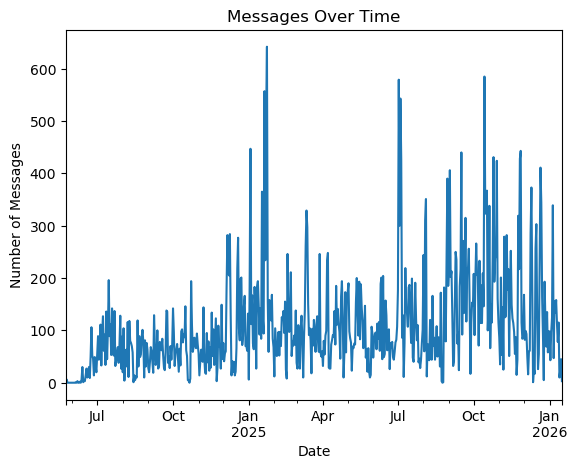

In [10]:
#Messages Per Day
df.set_index('Message Date').resample('D').count()['Text'].plot()
plt.title("Messages Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Messages")
plt.show()

In [19]:
df_her = df[df['Type'] == "Incoming"]
df_me = df[df['Type'] == "Outgoing"]

In [11]:
#VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if isinstance(text, str):
        return sia.polarity_scores(text)['compound'] #Compound gets the weighted sum of sentiment scores
    return None

df['Sentiment'] = df['Text'].apply(get_sentiment)

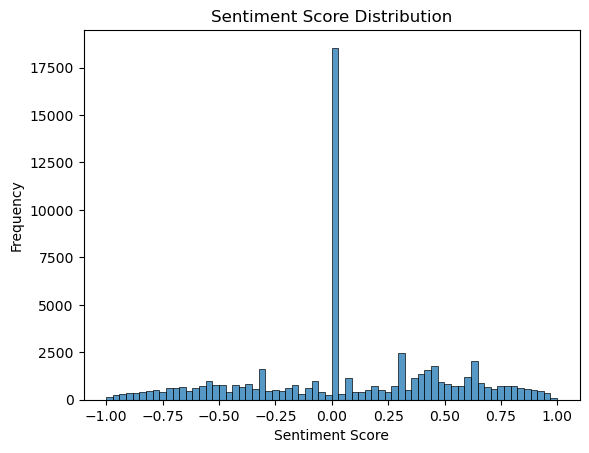

In [12]:
#Sentiment Distribution
sns.histplot(df['Sentiment']) 
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

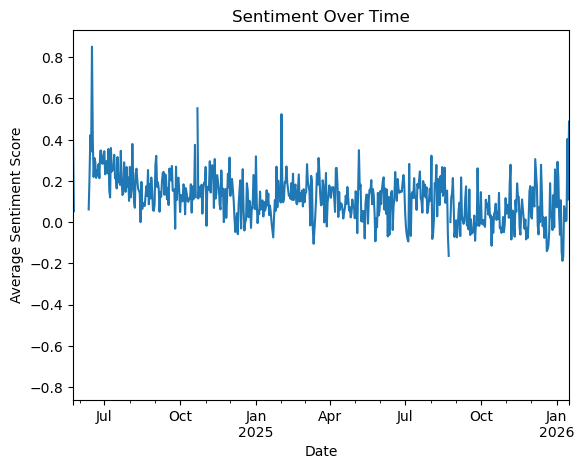

In [13]:
#Daily Average Sentiment Over Time
df.set_index('Message Date').resample('D')['Sentiment'].mean().plot()
plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

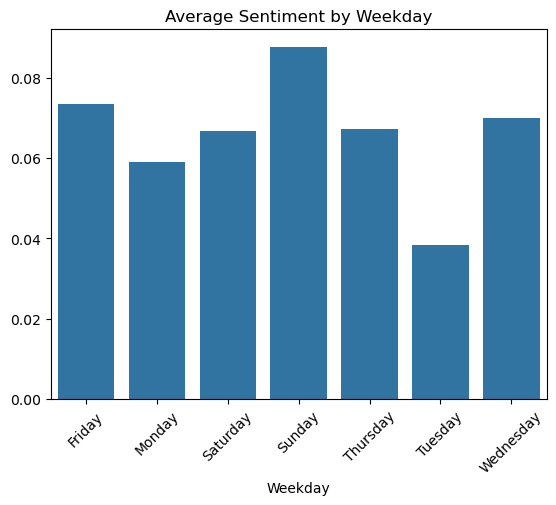

In [14]:
#Average Sentiment by Weekday
sns.barplot(x=df.groupby("Weekday")['Sentiment'].mean().index, y=df.groupby("Weekday")['Sentiment'].mean().values)
plt.xticks(rotation=45)
plt.title("Average Sentiment by Weekday")
plt.show()

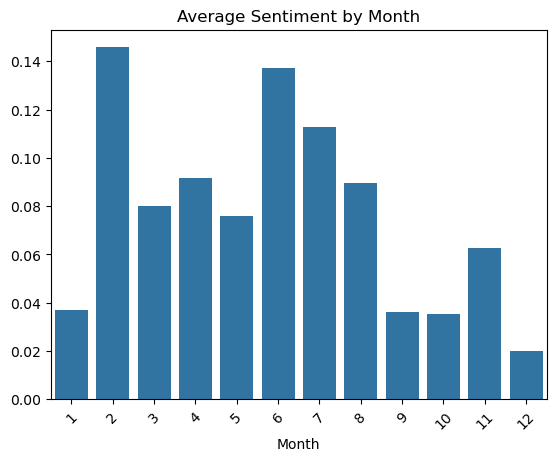

In [15]:
#Average Sentiment by Month
sns.barplot(x=df.groupby("Month")['Sentiment'].mean().index, y=df.groupby("Month")['Sentiment'].mean().values)
plt.xticks(rotation=45)
plt.title("Average Sentiment by Month")
plt.show()

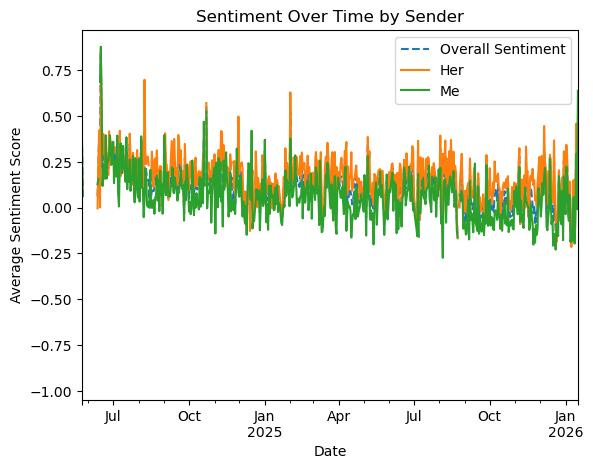

In [16]:
df.set_index('Message Date').resample('D')['Sentiment'].mean().plot(label='Overall Sentiment', linestyle='dashed')

#Split by sender
for sender in ['Her', 'Me']:
    df[df['Sender'] == sender].set_index('Message Date').resample('D')['Sentiment'].mean().plot(label=sender)

plt.title("Sentiment Over Time by Sender")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.show()

In [17]:
#Sentiment Summary Statistics
print(df['Sentiment'].describe())

mean_sentiment_by_sender = df.groupby('Sender')['Sentiment'].mean()
print(mean_sentiment_by_sender)

count    65542.000000
mean         0.065692
std          0.446560
min         -1.000000
25%         -0.176100
50%          0.000000
75%          0.421500
max          0.998800
Name: Sentiment, dtype: float64
Sender
Her    0.120035
Me     0.001160
Name: Sentiment, dtype: float64


In [18]:
#Most Positive and Negative Messages
#print(df.nlargest(5, 'Sentiment')[['Message Date', 'Text', 'Sentiment']])
#print(df.nsmallest(5, 'Sentiment')[['Message Date', 'Text', 'Sentiment']])